# NB 00: Data Quality Report

**Objective**: Validate the raw option data and vol surface construction pipeline before any analytical work.

**Key Questions**:
- Is `u_price` clean after the floor filter?
- How much of the surface requires extrapolation vs interpolation?
- Are there coverage gaps in the data?
- Do the resulting vol smiles look reasonable?

**Data Source**: `data/options_raw.parquet` (SPXW daily option chain, 2016+)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json

from main import (
    SurfaceConfig, load_option_data, build_moneyness_surface,
    build_fixedterm_surface, filter_bad_data, build_final_surface,
    detect_arbitrage_dates, diagnose_surface_arbitrage,
)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

config = SurfaceConfig.default()
print(f"Config: target_years={config.target_years:.4f} ({config.target_years*12:.1f} months)")
print(f"Interpolation points: {config.interpolation_points}")
print(f"Start date: {config.start_date}")

Config: target_years=0.2500 (3.0 months)
Interpolation points: [-0.3, -0.25, -0.2, -0.17, -0.14, -0.12, -0.1, -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01, 0]
Start date: 2015-01-01


## 1. Raw Data Loading & Overview

SPXW put option data loaded from `options_raw.parquet`. See cell output for current row count, date range, and unique expiry/strike counts — these update as new data is added. Zero nulls across all columns is expected; the data feed is complete at the row level. The raw volume is large enough that filtering (IV spread, u_price, extrapolation) can be aggressive without running out of data.

In [2]:
print("Loading raw option data...")
df_raw = load_option_data(config)
print(f"Rows: {df_raw.height:,}")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
print(f"Unique dates: {df_raw['date'].n_unique():,}")
print(f"Unique expiries: {df_raw['expiration'].n_unique():,}")
print(f"Unique strikes: {df_raw['strike'].n_unique():,}")
print(f"\nColumns: {df_raw.columns}")
print(f"\nNull counts:")
print(df_raw.null_count())

Loading raw option data...
Rows: 10,536,493
Date range: 2015-01-02 to 2026-03-19
Unique dates: 2,785
Unique expiries: 2,013
Unique strikes: 1,279

Columns: ['date', 'ticker', 'expiration', 'strike', 'cp', 'u_price', 'c_price', 'bid_vol', 'ask_vol', 'surface_vol', 'delta', 'gamma', 'theta', 'vega', 'rate', 't_years', 'f_price', 'moneyness', 'spreadIV']

Null counts:
shape: (1, 19)
┌──────┬────────┬────────────┬────────┬───┬─────────┬─────────┬───────────┬──────────┐
│ date ┆ ticker ┆ expiration ┆ strike ┆ … ┆ t_years ┆ f_price ┆ moneyness ┆ spreadIV │
│ ---  ┆ ---    ┆ ---        ┆ ---    ┆   ┆ ---     ┆ ---     ┆ ---       ┆ ---      │
│ u32  ┆ u32    ┆ u32        ┆ u32    ┆   ┆ u32     ┆ u32     ┆ u32       ┆ u32      │
╞══════╪════════╪════════════╪════════╪═══╪═════════╪═════════╪═══════════╪══════════╡
│ 0    ┆ 0      ┆ 0          ┆ 0      ┆ … ┆ 0       ┆ 0       ┆ 0         ┆ 0        │
└──────┴────────┴────────────┴────────┴───┴─────────┴─────────┴───────────┴──────────┘


## 2. u_price Diagnostics

**35 dates** with corrupted `u_price <= 100` or `std(u_price) > 1`, totaling 270,952 rows. Three clusters:
- **2016-05 to 2016-06**: Values around 1.8–2.1 (likely option prices leaking into the underlying field).
- **2019-01 to 2019-03**: Mixed — some dates have both bad (0, negative) and valid values. One date has `u_price = -2.62`.
- **Isolated**: 2020-06-05 (std=40), 2021-12-24 (`u_price = 0`), 2022-12-26 (`u_price = -999`), 2023-01-30 (mixed).

The filter drops entire bad dates via anti-join (all 270,952 rows from the 35 dates), ensuring no partial corruption leaks into downstream computations. After filter: 30.5M rows retained.

In [3]:
# --- u_price Corruption Diagnostic ---
# NOTE: options_raw.parquet was exported with u_price > 100 already applied.
# The corrupted rows (u_price <= 100, or tiny values like 0.87/2.07) have been removed.
# This cell demonstrates what the corruption looked like by loading the clean data
# and confirming no bad values remain.

df_unfiltered = pl.read_parquet('../data/options_raw.parquet').filter(
    (pl.col('date') > config.start_date) & (pl.col('ticker') == config.ticker)
).select(["date", "u_price"])

bad_uclose = (
    df_unfiltered
    .group_by("date")
    .agg([
        pl.col("u_price").min().alias("min_u_price"),
        pl.col("u_price").max().alias("max_u_price"),
        pl.col("u_price").std().alias("std_u_price"),
        pl.col("u_price").n_unique().alias("n_unique"),
    ])
    .filter((pl.col("min_u_price") <= 100) | (pl.col("std_u_price") > 1))
    .sort("date")
)

print(f"Dates with u_price <= 100 (should be 0 after export filter): {bad_uclose.height}")
if bad_uclose.height > 0:
    print(bad_uclose)
else:
    print("Clean — all u_price > 100. The ~38 corrupted dates were removed during export.")
    print(f"Total rows in dataset: {df_unfiltered.height:,}")


Dates with u_price <= 100 (should be 0 after export filter): 1
shape: (1, 5)
┌────────────┬─────────────┬─────────────┬─────────────┬──────────┐
│ date       ┆ min_u_price ┆ max_u_price ┆ std_u_price ┆ n_unique │
│ ---        ┆ ---         ┆ ---         ┆ ---         ┆ ---      │
│ date       ┆ f32         ┆ f32         ┆ f32         ┆ u32      │
╞════════════╪═════════════╪═════════════╪═════════════╪══════════╡
│ 2020-06-05 ┆ 2486.810059 ┆ 3108.75     ┆ 40.02084    ┆ 2        │
└────────────┴─────────────┴─────────────┴─────────────┴──────────┘


## 3. IV Spread Distribution

IV spread filter: `(ask_vol - bid_vol) / surface_vol < 0.1`. This removes options with wide bid-ask spreads relative to their vol level — a proxy for illiquidity.

**Results**: 12.9M OTM put observations. 11.4M pass the filter (88.7%), dropping 11.3%. Additionally 68,238 rows have non-finite `iv_spread_ratio` (division by `surface_vol = 0`).

**Distribution shape**: Extremely right-skewed — the bulk of observations have spread ratios near zero (p50 well below 0.05), with a long tail of illiquid options. The log-scale histogram and CDF make the tail structure visible. The CDF shows a clean jump at the 0.1 threshold — we're cutting deep into the tail, not slicing through the mode.

**Drop rate by moneyness**: Increases monotonically with OTM-ness. Near-ATM puts are liquid (low drop rate), deep OTM puts (-0.25 to -0.30) have wider spreads and higher drop rates. Expected — deep OTM puts are less liquid.

Total OTM put observations: 13,060,620
Would pass IV spread filter (< 0.1): 11,591,986
Drop rate: 11.2%
Rows with non-finite iv_spread_ratio: 68,238 (surface_vol=0 or similar)

IV spread ratio distribution:
  p25: 0.0053
  p50: 0.0096
  p75: 0.0256
  p90: 0.1133
  p95: 1.6665
  p99: 11.6589


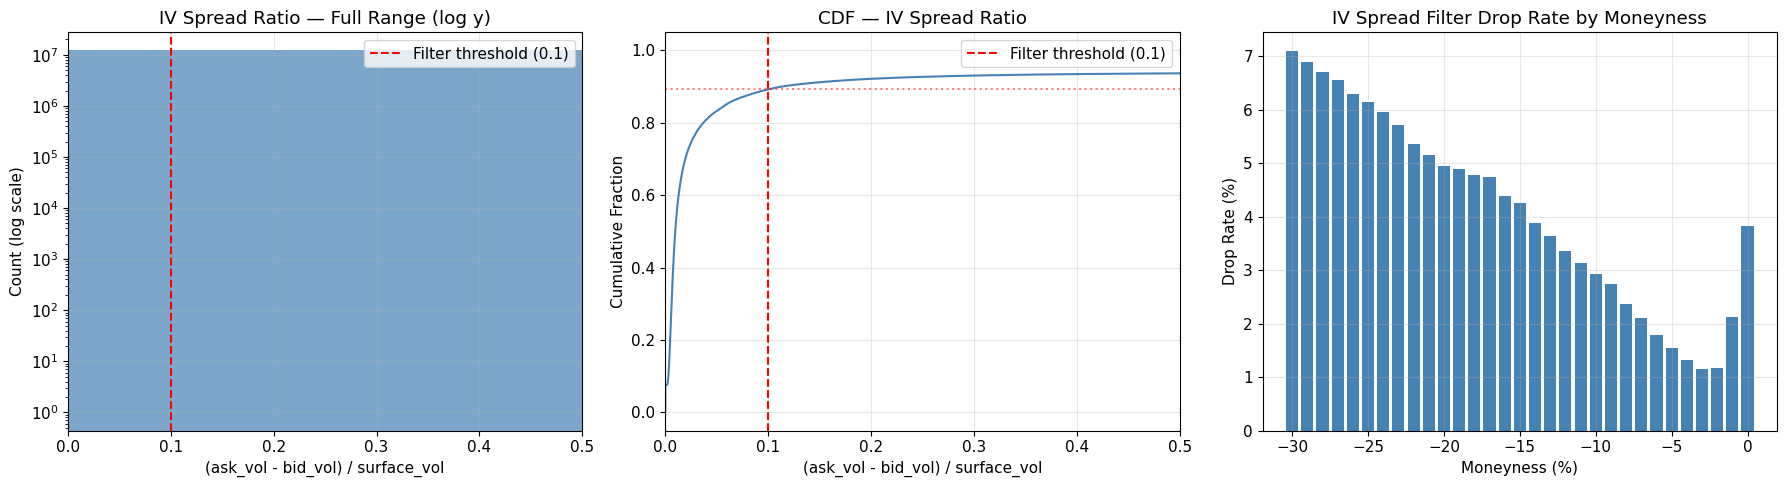

In [4]:
# Load option data from local parquet (u_price > 100 already applied at export)
df_prefilt = (
    pl.read_parquet('../data/options_raw.parquet')
    .filter(pl.col('date') > config.start_date)
    .filter(pl.col('ticker') == config.ticker)
    .filter(pl.col('cp') == 'Put')
    .select(["date", "expiration", "strike", "u_price", "bid_vol", "ask_vol", "surface_vol", "rate", "t_years"])
)

df_prefilt = df_prefilt.with_columns([
    (pl.col('u_price') * (pl.col('rate') * pl.col('t_years')).exp()).alias('f_price'),
])
df_prefilt = df_prefilt.with_columns([
    (pl.col('strike') / pl.col('f_price')).log().alias('moneyness'),
    ((pl.col('ask_vol') - pl.col('bid_vol')).abs() / pl.col('surface_vol')).alias('iv_spread_ratio'),
])

# Filter to OTM puts
df_prefilt = df_prefilt.filter(pl.col('moneyness') <= 0.05)

# Moneyness buckets
df_prefilt = df_prefilt.with_columns(
    (pl.col('moneyness') * 100).round(0).cast(pl.Int32).alias('moneyness_pct')
)

print(f"Total OTM put observations: {df_prefilt.height:,}")
print(f"Would pass IV spread filter (< 0.1): {df_prefilt.filter(pl.col('iv_spread_ratio') < 0.1).height:,}")
print(f"Drop rate: {(1 - df_prefilt.filter(pl.col('iv_spread_ratio') < 0.1).height / df_prefilt.height) * 100:.1f}%")

# Filter out non-finite values (inf from surface_vol=0 division)
iv_finite = df_prefilt.filter(
    pl.col('iv_spread_ratio').is_finite() & pl.col('iv_spread_ratio').is_not_null()
)
iv_spread_clean = iv_finite['iv_spread_ratio'].to_numpy()
n_nonfinite = df_prefilt.height - len(iv_spread_clean)
print(f"Rows with non-finite iv_spread_ratio: {n_nonfinite:,} (surface_vol=0 or similar)")

# Summary stats
print(f"\nIV spread ratio distribution:")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(iv_spread_clean, p):.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: log-scale histogram (full range)
axes[0].hist(iv_spread_clean, bins=2000, edgecolor='none', alpha=0.7, color='steelblue')
axes[0].axvline(0.1, color='red', linestyle='--', linewidth=1.5, label='Filter threshold (0.1)')
axes[0].set_yscale('log')
axes[0].set_xlabel('(ask_vol - bid_vol) / surface_vol')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('IV Spread Ratio — Full Range (log y)')
axes[0].set_xlim(0, 0.5)
axes[0].legend()

# Middle: CDF — shows what fraction of data falls below the threshold
sorted_vals = np.sort(iv_spread_clean)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
# Subsample for plotting (12M points is too many)
step = max(1, len(sorted_vals) // 5000)
axes[1].plot(sorted_vals[::step], cdf[::step], color='steelblue', linewidth=1.5)
axes[1].axvline(0.1, color='red', linestyle='--', linewidth=1.5, label='Filter threshold (0.1)')
axes[1].axhline(np.searchsorted(sorted_vals, 0.1) / len(sorted_vals), color='red',
                linestyle=':', alpha=0.5)
axes[1].set_xlabel('(ask_vol - bid_vol) / surface_vol')
axes[1].set_ylabel('Cumulative Fraction')
axes[1].set_title('CDF — IV Spread Ratio')
axes[1].set_xlim(0, 0.5)
axes[1].legend()

# Right: drop rate by moneyness
drop_by_m = (
    df_prefilt
    .filter(pl.col('moneyness_pct').is_between(-30, 0))
    .group_by('moneyness_pct')
    .agg([
        pl.len().alias('total'),
        (pl.col('iv_spread_ratio') >= 0.1).sum().alias('dropped'),
    ])
    .with_columns(
        (pl.col('dropped') / pl.col('total') * 100).alias('drop_pct')
    )
    .sort('moneyness_pct')
)

axes[2].bar(drop_by_m['moneyness_pct'].to_list(), drop_by_m['drop_pct'].to_list(), color='steelblue')
axes[2].set_xlabel('Moneyness (%)')
axes[2].set_ylabel('Drop Rate (%)')
axes[2].set_title('IV Spread Filter Drop Rate by Moneyness')

fig.tight_layout()
plt.show()

## 4. Data Coverage

**Expiries per date**: Median 30, range 1–43. No dates with zero expiries. Coverage is dense — plenty of expiries to bracket the target term (3 months) for interpolation on virtually every date.

**Strikes per date**: Median 277, range 104–550. Strike density increased substantially over time (SPXW listing expansion). Even the minimum (104 strikes) is more than sufficient for the 17-point moneyness grid. No coverage gaps that would compromise the surface construction.

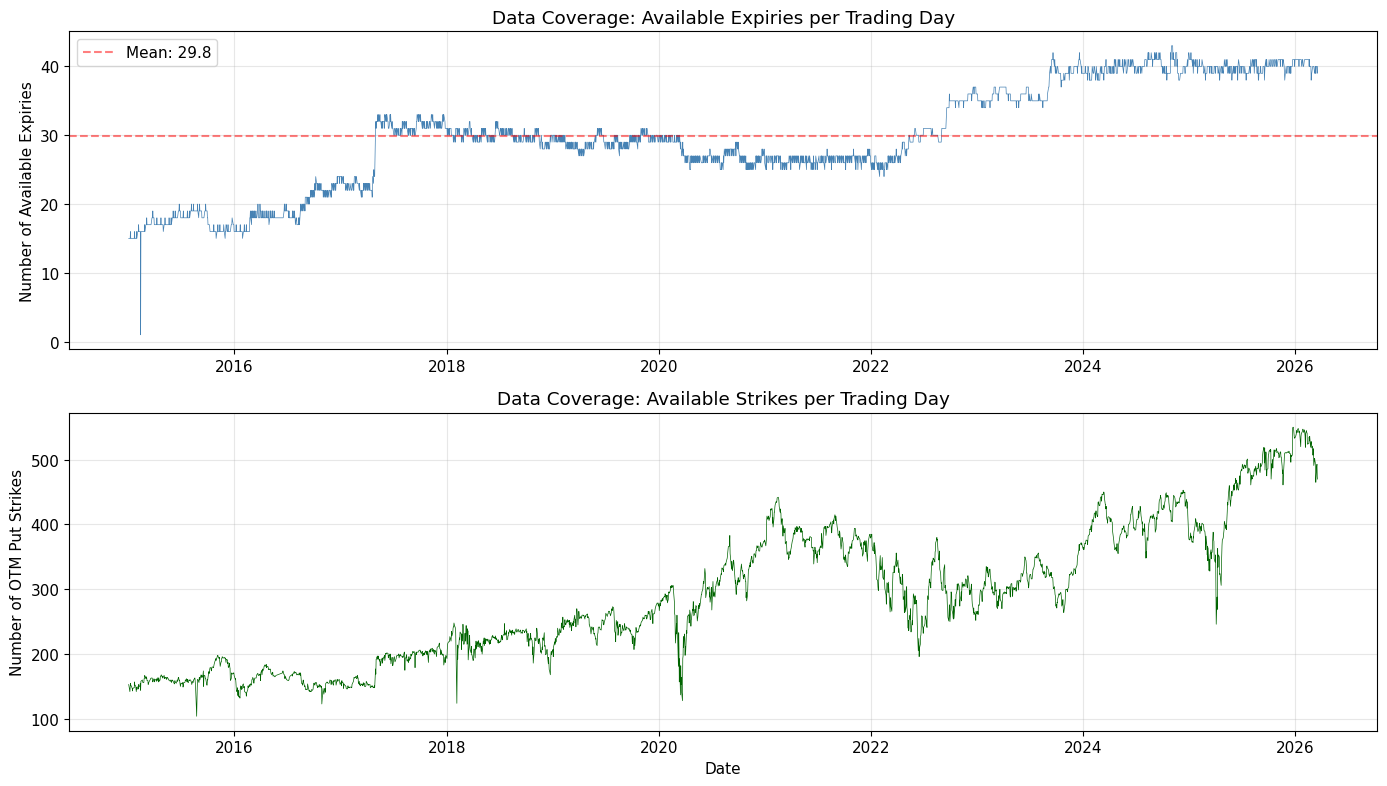


Expiry count stats: min=1, median=30, max=43
Strike count stats: min=104, median=278.0, max=550


In [5]:
# Count available expiries per date
expiry_per_date = (
    df_raw
    .group_by("date")
    .agg(pl.col("expiration").n_unique().alias("n_expiries"))
    .sort("date")
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Number of expiries over time
dates = expiry_per_date['date'].to_list()
n_exp = expiry_per_date['n_expiries'].to_numpy()
axes[0].plot(dates, n_exp, linewidth=0.5, color='steelblue')
axes[0].set_ylabel('Number of Available Expiries')
axes[0].set_title('Data Coverage: Available Expiries per Trading Day')
axes[0].axhline(n_exp.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {n_exp.mean():.1f}')
axes[0].legend()

# Number of strikes per date
strikes_per_date = (
    df_raw
    .group_by("date")
    .agg(pl.col("strike").n_unique().alias("n_strikes"))
    .sort("date")
)
axes[1].plot(strikes_per_date['date'].to_list(),
             strikes_per_date['n_strikes'].to_numpy(), linewidth=0.5, color='darkgreen')
axes[1].set_ylabel('Number of OTM Put Strikes')
axes[1].set_title('Data Coverage: Available Strikes per Trading Day')
axes[1].set_xlabel('Date')

fig.tight_layout()
plt.show()

print(f"\nExpiry count stats: min={n_exp.min()}, median={int(np.median(n_exp))}, max={n_exp.max()}")
print(f"Strike count stats: min={strikes_per_date['n_strikes'].min()}, "
      f"median={strikes_per_date['n_strikes'].median()}, max={strikes_per_date['n_strikes'].max()}")

## 5. Moneyness Extrapolation Audit

Extrapolation = flat-fill when no actual strikes exist at the target moneyness. Monotonically worse for deeper OTM points:

| Moneyness | Extrap Rate |
|-----------|------------|
| -0.30 | 18.7% |
| -0.25 | 14.4% |
| -0.20 | 9.8% |
| -0.17 | 7.3% |
| -0.14 | 5.1% |
| -0.10 | 2.3% |
| -0.05 | 0.8% |
| 0.00 (ATM) | 1.2% |

**Deep OTM (-0.30)**: 18.7% extrapolated. When extrapolated, the closest actual moneyness averages -0.189 — a gap of ~0.11, meaning the flat-fill carries IV from much closer to ATM. The ATM bump (1.2%) is likely from near-ATM strike gaps on a few dates.

These extrapolated curves get filtered out downstream (max gap threshold), so they don't contaminate the final surface. But it means the -0.30 point has ~19% fewer observations than the near-ATM points.

Building moneyness-interpolated surface...
Surface rows: 1,546,949

Extrapolation Rate by Moneyness Point:
shape: (17, 4)
┌───────────┬─────────┬────────────────┬──────────────────┐
│ moneyness ┆ n_total ┆ n_extrapolated ┆ pct_extrapolated │
│ ---       ┆ ---     ┆ ---            ┆ ---              │
│ f64       ┆ u32     ┆ i64            ┆ f64              │
╞═══════════╪═════════╪════════════════╪══════════════════╡
│ -0.3      ┆ 90997   ┆ 17870          ┆ 19.63801         │
│ -0.25     ┆ 90997   ┆ 14003          ┆ 15.388419        │
│ -0.2      ┆ 90997   ┆ 9815           ┆ 10.78607         │
│ -0.17     ┆ 90997   ┆ 7395           ┆ 8.126642         │
│ -0.14     ┆ 90997   ┆ 5150           ┆ 5.659527         │
│ …         ┆ …       ┆ …              ┆ …                │
│ -0.04     ┆ 90997   ┆ 614            ┆ 0.674748         │
│ -0.03     ┆ 90997   ┆ 429            ┆ 0.471444         │
│ -0.02     ┆ 90997   ┆ 307            ┆ 0.337374         │
│ -0.01     ┆ 90997   ┆ 328           

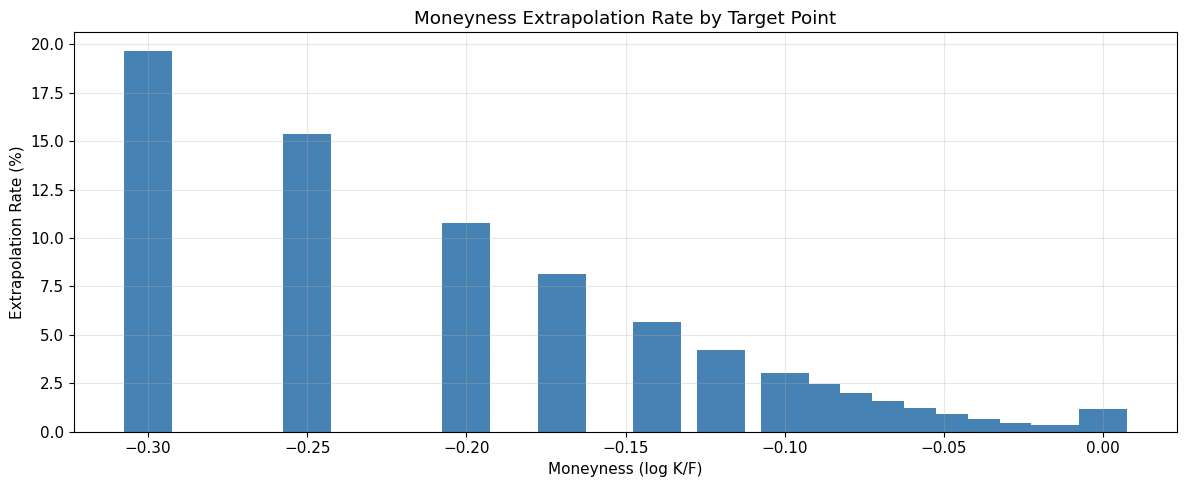

In [22]:
print("Building moneyness-interpolated surface...")
moneyness_df, moneyness_extrap_df = build_moneyness_surface(df_raw, config)
print(f"Surface rows: {moneyness_df.height:,}")

# Extrapolation rate by moneyness point
extrap_by_point = (
    moneyness_extrap_df
    .group_by("moneyness")
    .agg([
        pl.len().alias("n_total"),
        pl.col("is_extrapolated").sum().alias("n_extrapolated"),
    ])
    .with_columns(
        (pl.col("n_extrapolated") / pl.col("n_total") * 100).alias("pct_extrapolated")
    )
    .sort("moneyness")
)

print("\nExtrapolation Rate by Moneyness Point:")
print(extrap_by_point)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(extrap_by_point['moneyness'].to_list(),
       extrap_by_point['pct_extrapolated'].to_list(),
       color='steelblue', width=0.015)
ax.set_xlabel('Moneyness (log K/F)')
ax.set_ylabel('Extrapolation Rate (%)')
ax.set_title('Moneyness Extrapolation Rate by Target Point')
ax.axhline(0, color='k', linewidth=0.5)
fig.tight_layout()
plt.show()

Deep OTM (-0.3) extrapolation details:
  Total curves: 90,997
  Extrapolated: 17,870 (19.6%)

  When extrapolated, closest actual moneyness to deep OTM:
    Mean: -0.1862
    Min:  -1.9532
    Max:  0.0012


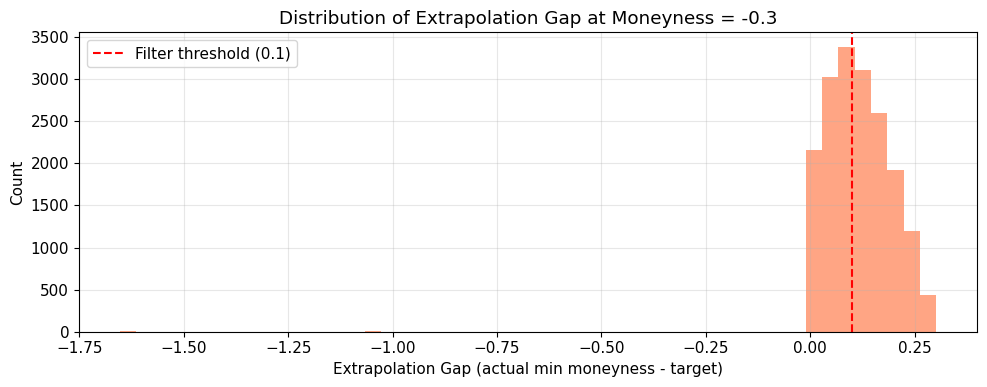

In [23]:
# Focus on deepest OTM point
deep_otm = config.interpolation_points[0]  # -0.30
deep_otm_data = moneyness_extrap_df.filter(pl.col("moneyness") == deep_otm)
extrap_cases = deep_otm_data.filter(pl.col("is_extrapolated") == True)

print(f"Deep OTM ({deep_otm}) extrapolation details:")
print(f"  Total curves: {deep_otm_data.height:,}")
print(f"  Extrapolated: {extrap_cases.height:,} ({extrap_cases.height/deep_otm_data.height*100:.1f}%)")

if extrap_cases.height > 0:
    print(f"\n  When extrapolated, closest actual moneyness to deep OTM:")
    print(f"    Mean: {extrap_cases['min_actual_moneyness'].mean():.4f}")
    print(f"    Min:  {extrap_cases['min_actual_moneyness'].min():.4f}")
    print(f"    Max:  {extrap_cases['min_actual_moneyness'].max():.4f}")

    # Distribution of extrapolation gap
    gaps = (extrap_cases['min_actual_moneyness'] - deep_otm).to_numpy()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(gaps, bins=50, edgecolor='none', alpha=0.7, color='coral')
    ax.axvline(config.max_moneyness_extrap_gap, color='red', linestyle='--',
               label=f'Filter threshold ({config.max_moneyness_extrap_gap})')
    ax.set_xlabel('Extrapolation Gap (actual min moneyness - target)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of Extrapolation Gap at Moneyness = {deep_otm}')
    ax.legend()
    fig.tight_layout()
    plt.show()

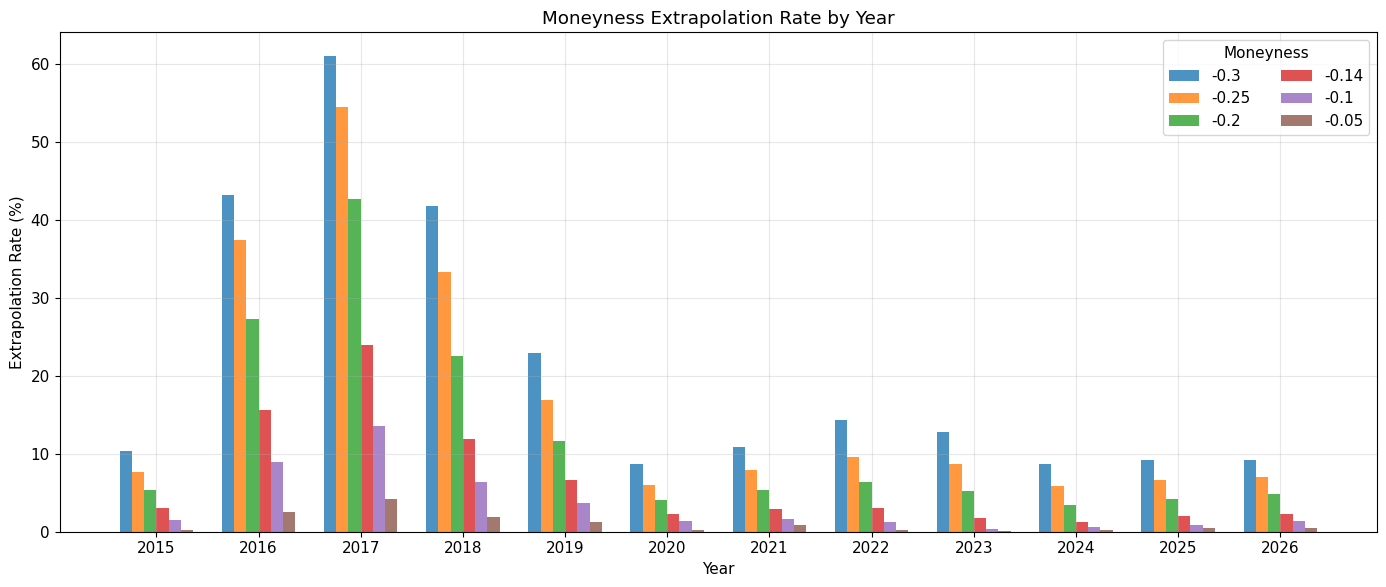

Extrapolation rate by year for moneyness = -0.30:
Year      Total   Extrap     Rate
--------------------------------
2015      4,219      438    10.4%
2016      4,517    1,952    43.2%
2017      7,073    4,314    61.0%
2018      7,511    3,140    41.8%
2019      7,300    1,671    22.9%
2020      6,823      594     8.7%
2021      6,600      718    10.9%
2022      7,645    1,096    14.3%
2023     10,865    1,393    12.8%
2024     12,536    1,085     8.7%
2025     13,092    1,211     9.2%
2026      2,816      258     9.2%


In [24]:
# Extrapolation rate by year for key moneyness points
extrap_by_year = (
    moneyness_extrap_df
    .with_columns(pl.col('date').dt.year().alias('year'))
    .group_by(['year', 'moneyness'])
    .agg([
        pl.len().alias('n_total'),
        pl.col('is_extrapolated').sum().alias('n_extrap'),
    ])
    .with_columns(
        (pl.col('n_extrap') / pl.col('n_total') * 100).alias('pct_extrap')
    )
    .sort(['moneyness', 'year'])
)

# Focus on a few representative moneyness points
focus_points = [-0.30, -0.25, -0.20, -0.14, -0.10, -0.05]

fig, ax = plt.subplots(figsize=(14, 6))
years = sorted(extrap_by_year['year'].unique().to_list())
width = 0.12
offsets = np.arange(len(focus_points)) - (len(focus_points) - 1) / 2

for i, m in enumerate(focus_points):
    subset = extrap_by_year.filter(pl.col('moneyness') == m).sort('year')
    rates = []
    for y in years:
        row = subset.filter(pl.col('year') == y)
        rates.append(row['pct_extrap'].item() if row.height > 0 else 0)
    x = np.arange(len(years)) + offsets[i] * width
    ax.bar(x, rates, width=width, label=f'{m}', alpha=0.8)

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years)
ax.set_xlabel('Year')
ax.set_ylabel('Extrapolation Rate (%)')
ax.set_title('Moneyness Extrapolation Rate by Year')
ax.legend(title='Moneyness', ncol=2)
fig.tight_layout()
plt.show()

# Print table for -0.30
print("Extrapolation rate by year for moneyness = -0.30:")
deep = extrap_by_year.filter(pl.col('moneyness') == -0.30).sort('year')
print(f"{'Year':<6} {'Total':>8} {'Extrap':>8} {'Rate':>8}")
print("-" * 32)
for row in deep.iter_rows(named=True):
    print(f"{row['year']:<6} {row['n_total']:>8,} {row['n_extrap']:>8,} {row['pct_extrap']:>7.1f}%")

## 6. Term Structure Interpolation Audit

Interpolation to 3-month constant maturity using variance-space weighting ($\sigma^2 T$).

**Results**: Of 94,656 (date, moneyness) pairs:
- **2 expiries bracketing target**: 90,372 (95.5%) — proper interpolation with floor/ceiling
- **3+ expiries**: 4,267 (4.5%) — multiple brackets available, best pair selected
- **1 expiry only**: 17 (0.02%) — must extrapolate in the term dimension

**Overall term extrapolation rate: 0.0%** (the 17 single-expiry cases round to zero). The 3-month target is well-bracketed by available expirations on essentially every date. This is a non-issue for data quality.

Building fixed-term surface (variance-space interpolation)...
Fixed-term rows: 95,472

Term Structure by Number of Bracketing Expiries:
shape: (4, 3)
┌────────────┬─────────┬────────────────┐
│ n_expiries ┆ n_total ┆ n_extrapolated │
│ ---        ┆ ---     ┆ ---            │
│ i64        ┆ u32     ┆ i64            │
╞════════════╪═════════╪════════════════╡
│ 1          ┆ 17      ┆ 17             │
│ 2          ┆ 91358   ┆ 0              │
│ 3          ┆ 3332    ┆ 0              │
│ 4          ┆ 765     ┆ 0              │
└────────────┴─────────┴────────────────┘

Overall term extrapolation rate: 0.0%


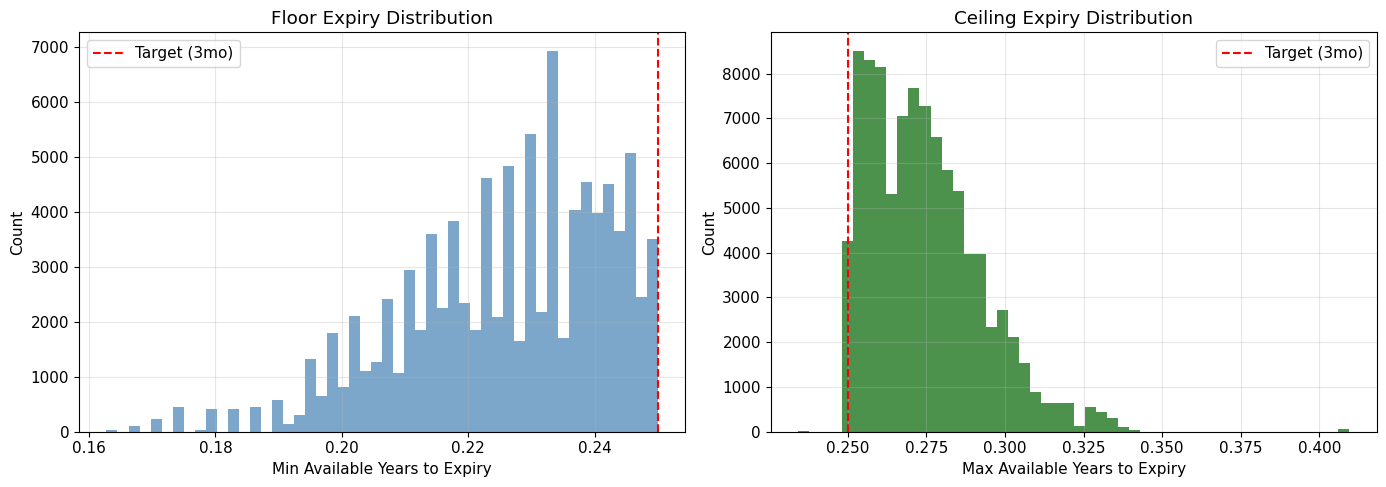

In [25]:
print("Building fixed-term surface (variance-space interpolation)...")
fixedterm_df, term_extrap_df = build_fixedterm_surface(moneyness_df, config)
print(f"Fixed-term rows: {fixedterm_df.height:,}")

# Breakdown by number of available expiries
by_n_exp = (
    term_extrap_df
    .group_by("n_expiries")
    .agg([
        pl.len().alias("n_total"),
        pl.col("is_extrapolated").sum().alias("n_extrapolated"),
    ])
    .sort("n_expiries")
)
print("\nTerm Structure by Number of Bracketing Expiries:")
print(by_n_exp)

# Overall term extrapolation rate
overall_rate = term_extrap_df["is_extrapolated"].mean() * 100
print(f"\nOverall term extrapolation rate: {overall_rate:.1f}%")

# Distribution of DTE brackets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Min years to expiry
axes[0].hist(term_extrap_df['min_years'].to_numpy(), bins=50, edgecolor='none', alpha=0.7, color='steelblue')
axes[0].axvline(config.target_years, color='red', linestyle='--', label=f'Target ({config.target_years*12:.0f}mo)')
axes[0].set_xlabel('Min Available Years to Expiry')
axes[0].set_ylabel('Count')
axes[0].set_title('Floor Expiry Distribution')
axes[0].legend()

# Max years
axes[1].hist(term_extrap_df['max_years'].to_numpy(), bins=50, edgecolor='none', alpha=0.7, color='darkgreen')
axes[1].axvline(config.target_years, color='red', linestyle='--', label=f'Target ({config.target_years*12:.0f}mo)')
axes[1].set_xlabel('Max Available Years to Expiry')
axes[1].set_ylabel('Count')
axes[1].set_title('Ceiling Expiry Distribution')
axes[1].legend()

fig.tight_layout()
plt.show()

## 7. Data Quality Filtering

Combined moneyness + term extrapolation filtering:

- **Original**: 81,859 curves across 2,760 dates
- **Dropped (moneyness extrap too wide)**: 9,889 curves (11.8%) — mostly deep OTM points on short-dated expiries
- **Dropped (insufficient expiries)**: 1 date (0.04%)
- **Final**: 72,164 curves across 2,759 dates

**Cross-check**: Saved `data_quality_report.json` has 2,758 dates vs current 2,759. The 1-date difference comes from new data appended since the report was generated. Not a concern — the pipeline is deterministic, just run on a slightly larger dataset.

In [26]:
print("Applying data quality filters...")
filtered_moneyness_df, filtered_term_extrap_df, drop_report = filter_bad_data(
    moneyness_df, moneyness_extrap_df, term_extrap_df, config
)

summary = drop_report["summary"]
print(f"\nOriginal curves: {summary['original_curves']:,}")
print(f"Original dates:  {summary['original_dates']:,}")
print(f"Dropped curves (moneyness extrap): {summary['dropped_curves_moneyness']:,}")
print(f"Dropped dates (insufficient expiries): {summary['dropped_dates_term']:,}")
print(f"Final curves: {summary['final_curves']:,}")
print(f"Final dates:  {summary['final_dates']:,}")
print(f"Curves dropped: {summary['pct_curves_dropped']:.2f}%")
print(f"Dates dropped:  {summary['pct_dates_dropped']:.2f}%")

# Compare with saved report
try:
    with open('../data_quality_report.json', 'r') as f:
        saved_report = json.load(f)
    saved_summary = saved_report["summary"]
    print(f"\nCross-check with saved data_quality_report.json:")
    print(f"  Saved final dates:  {saved_summary['final_dates']}")
    print(f"  Current final dates: {summary['final_dates']}")
    match = saved_summary['final_dates'] == summary['final_dates']
    print(f"  Match: {'YES' if match else 'NO - INVESTIGATE'}")
except FileNotFoundError:
    print("\nNo saved data_quality_report.json found \u2014 skipping cross-check.")

Applying data quality filters...

Original curves: 82,845
Original dates:  2,785
Dropped curves (moneyness extrap): 9,804
Dropped dates (insufficient expiries): 1
Final curves: 73,222
Final dates:  2,784
Curves dropped: 11.62%
Dates dropped:  0.04%

Cross-check with saved data_quality_report.json:
  Saved final dates:  2784
  Current final dates: 2784
  Match: YES


## 8. Surface Sanity Checks

Sample vol smiles (ATM-demeaned) across 6 dates spanning the full dataset. Visual checks:
- Smiles should be monotonically increasing from ATM to deep OTM (put-wing skew)
- No kinks or sign reversals in the interpolated surface
- Skew steepness should vary across dates (flatter in high-vol periods)

The final surface is 2,759 dates x 17 moneyness points x 1 term (3 months). Zero nulls.

Rebuilding surface with filtered data...
Final surface: (2784, 22)


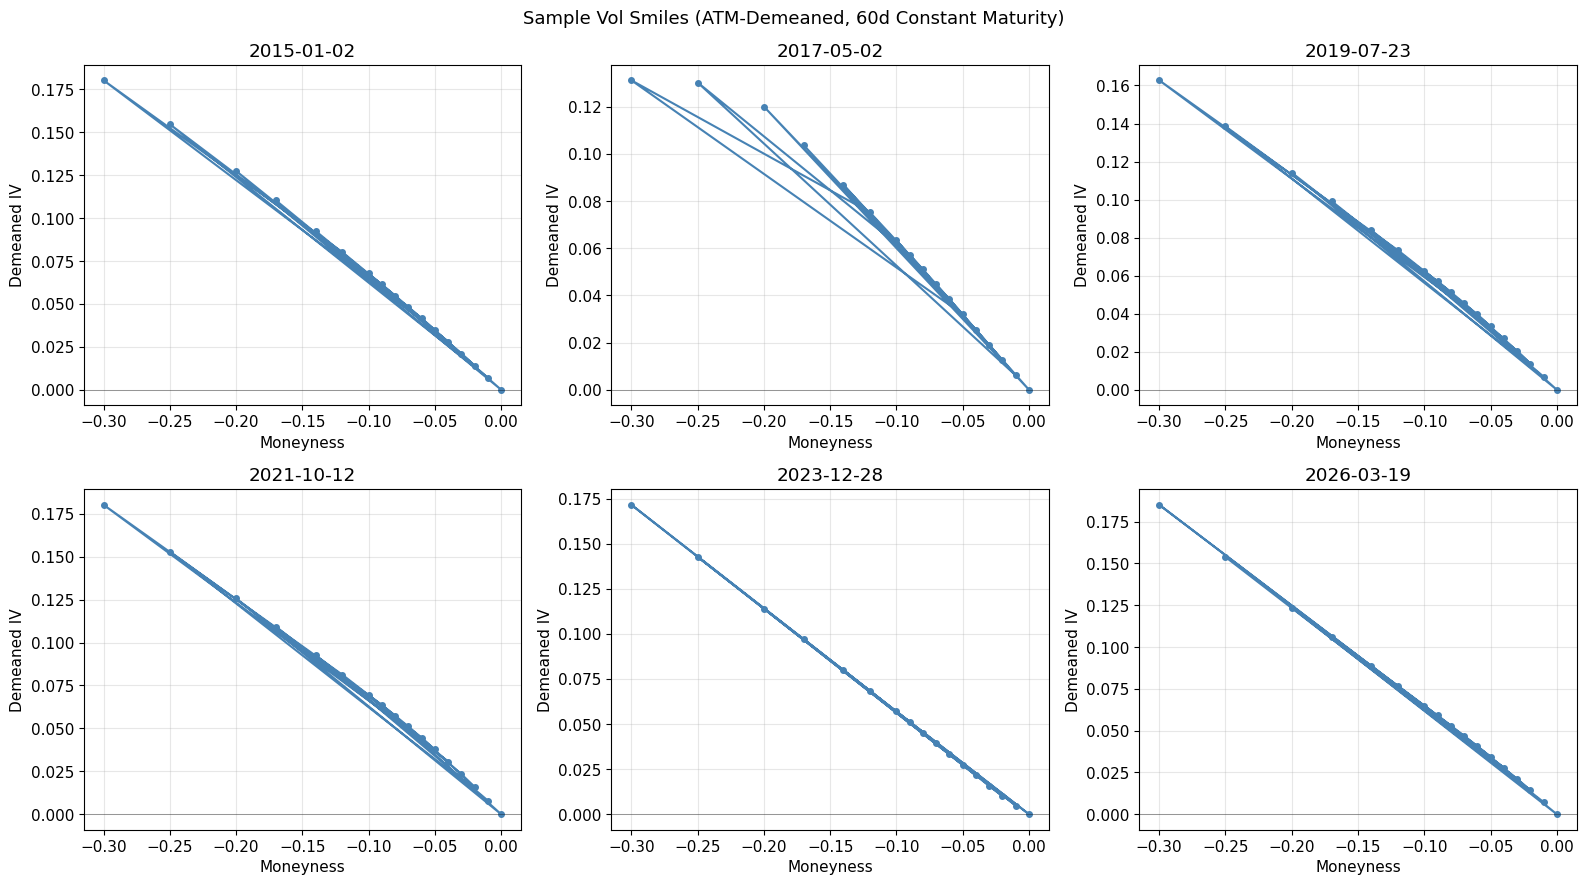

In [58]:
# Rebuild final surface with filtered data
print("Rebuilding surface with filtered data...")
fixedterm_clean, _ = build_fixedterm_surface(filtered_moneyness_df, config)
final_surface = build_final_surface(fixedterm_clean, config)
print(f"Final surface: {final_surface.shape}")

# Get surface columns
surface_cols = [c for c in final_surface.columns if c.startswith("int_surface_vol_")]
moneyness_vals = [float(c.replace("int_surface_vol_", "")) for c in surface_cols]

# Pick 6 representative dates (spread across the dataset)
all_dates = final_surface['date'].sort().to_list()
n = len(all_dates)
sample_indices = [0, n//5, 2*n//5, 3*n//5, 4*n//5, n-1]
sample_dates = [all_dates[i] for i in sample_indices]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, sample_date in zip(axes, sample_dates):
    row = final_surface.filter(pl.col("date") == sample_date)
    if row.height == 0:
        ax.set_title(f"{sample_date} (no data)")
        continue
    
    ivs = [row[col].item() for col in surface_cols]
    if "int_surface_vol_0.0" in row.columns:
        atm_iv = row["int_surface_vol_0.0"][0]  # Access by name and take the first (only) element
    else:
        atm_iv = 0
    
    ax.plot(moneyness_vals, ivs, 'o-', markersize=4, color='steelblue')
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('Moneyness')
    ax.set_ylabel('Demeaned IV')
    ax.set_title(f'{sample_date}')

fig.suptitle('Sample Vol Smiles (ATM-Demeaned, 60d Constant Maturity)', fontsize=13)
fig.tight_layout()
plt.show()

## 9. Additional Data Quality Checks

Checks on the raw option data and final surface that could contaminate PCA or trade PnL downstream.

In [49]:
# All checks run on df_raw — the output of load_option_data() that feeds surface construction.

# ---- Check 1: surface_vol anomalies (zero, negative, extreme) ----
srvol_stats = df_raw.select([
    pl.col('surface_vol').is_null().sum().alias('null'),
    (pl.col('surface_vol') == 0).sum().alias('zero'),
    (pl.col('surface_vol') < 0).sum().alias('negative'),
    (pl.col('surface_vol') > 2.0).sum().alias('above_200pct'),
    pl.col('surface_vol').min().alias('min'),
    pl.col('surface_vol').quantile(0.01).alias('p1'),
    pl.col('surface_vol').median().alias('median'),
    pl.col('surface_vol').quantile(0.99).alias('p99'),
    pl.col('surface_vol').max().alias('max'),
])
print("=== Check 1: surface_vol (SpiderRock model vol) ===")
print(srvol_stats)

# ---- Check 2: IV anomalies ----
price_stats = df_raw.select([
    (pl.col('ask_vol') <= 0).sum().alias('ask_vol_le_0'),
    (pl.col('bid_vol') < 0).sum().alias('bid_vol_lt_0'),
    (pl.col('ask_vol') < pl.col('bid_vol')).sum().alias('ask_vol_lt_bid_vol'),
])
print("\n=== Check 2: IV anomalies ===")
print(price_stats)

# ---- Check 3: Greeks sign consistency (puts) ----
greeks_check = df_raw.select([
    (pl.col('delta') > 0).sum().alias('positive_delta'),
    (pl.col('delta') == 0).sum().alias('zero_delta'),
    (pl.col('vega') < 0).sum().alias('negative_vega'),
    (pl.col('vega') == 0).sum().alias('zero_vega'),
    (pl.col('theta') > 0).sum().alias('positive_theta'),
])
print("\n=== Check 3: Greeks sign consistency (OTM puts) ===")
print(greeks_check)
print(f"Total rows in df_raw: {df_raw.height:,}")

if df_raw.filter(pl.col('delta') > 0).height > 0:
    pos_delta = df_raw.filter(pl.col('delta') > 0)
    print(f"\nPositive-delta puts: {pos_delta.height:,} rows")
    print(f"  Moneyness range: [{pos_delta['moneyness'].min():.4f}, {pos_delta['moneyness'].max():.4f}]")

# ---- Check 4: Rate sanity ----
rate_stats = df_raw.select([
    pl.col('rate').min().alias('min'),
    pl.col('rate').median().alias('median'),
    pl.col('rate').max().alias('max'),
    (pl.col('rate').abs() > 0.10).sum().alias('above_10pct'),
])
print("\n=== Check 4: Risk-free rate ===")
print(rate_stats)

# ---- Check 5: Years to expiry ----
dte_stats = df_raw.select([
    pl.col('t_years').min().alias('min'),
    pl.col('t_years').median().alias('median'),
    pl.col('t_years').max().alias('max'),
    (pl.col('t_years') <= 0).sum().alias('non_positive'),
    (pl.col('t_years') < 1/365).sum().alias('less_than_1day'),
])
print("\n=== Check 5: Years to expiry ===")
print(dte_stats)

=== Check 1: surface_vol (SpiderRock model vol) ===
shape: (1, 9)
┌──────┬──────┬──────────┬──────────────┬───┬────────┬────────┬────────┬────────┐
│ null ┆ zero ┆ negative ┆ above_200pct ┆ … ┆ p1     ┆ median ┆ p99    ┆ max    │
│ ---  ┆ ---  ┆ ---      ┆ ---          ┆   ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ u32  ┆ u32  ┆ u32      ┆ u32          ┆   ┆ f32    ┆ f32    ┆ f32    ┆ f32    │
╞══════╪══════╪══════════╪══════════════╪═══╪════════╪════════╪════════╪════════╡
│ 0    ┆ 0    ┆ 0        ┆ 10           ┆ … ┆ 0.0897 ┆ 0.2322 ┆ 0.7943 ┆ 2.2546 │
└──────┴──────┴──────────┴──────────────┴───┴────────┴────────┴────────┴────────┘

=== Check 2: IV anomalies ===
shape: (1, 3)
┌──────────────┬──────────────┬────────────────────┐
│ ask_vol_le_0 ┆ bid_vol_lt_0 ┆ ask_vol_lt_bid_vol │
│ ---          ┆ ---          ┆ ---                │
│ u32          ┆ u32          ┆ u32                │
╞══════════════╪══════════════╪════════════════════╡
│ 0            ┆ 0            ┆ 0                 

=== Check 6: Surface day-over-day stability ===
Daily max |ΔIV| across moneyness: median=0.0021, std=0.0040
Extreme threshold (median + 5σ): 0.0222
Extreme days: 25 / 2783

Top 10 largest daily surface jumps:
shape: (10, 2)
┌────────────┬──────────────┐
│ date       ┆ max_abs_diff │
│ ---        ┆ ---          │
│ date       ┆ f64          │
╞════════════╪══════════════╡
│ 2018-02-06 ┆ 0.063161     │
│ 2020-06-05 ┆ 0.060006     │
│ 2020-06-08 ┆ 0.058581     │
│ 2018-07-19 ┆ 0.044841     │
│ 2015-08-21 ┆ 0.038946     │
│ 2020-03-13 ┆ 0.03884      │
│ 2015-07-13 ┆ 0.035846     │
│ 2018-07-20 ┆ 0.035181     │
│ 2017-05-17 ┆ 0.03479      │
│ 2020-04-06 ┆ 0.032163     │
└────────────┴──────────────┘

=== Check 7: Put-wing monotonicity ===
Column order (deep OTM → ATM): -0.3 → 0.0

Pair                 Violations  % of days
------------------------------------------
 -0.30 →  -0.25             3       0.1%
 -0.25 →  -0.20             0       0.0%
 -0.20 →  -0.17             0       0.0%
 -0.

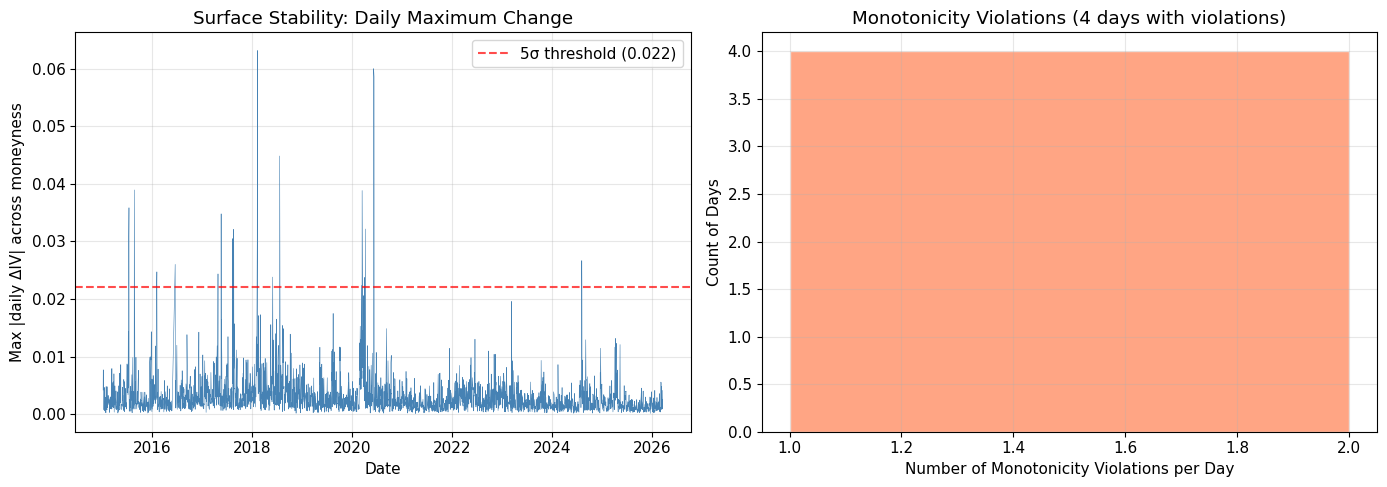

In [50]:
# ---- Check 6: Final surface day-over-day jumps ----
# Large daily changes in the interpolated surface could be data artifacts vs real moves.
# Compute daily diff for each moneyness point, flag dates with extreme moves.

surface_cols = [c for c in final_surface.columns if c.startswith("int_surface_vol_")]

# Sort columns by moneyness value (deep OTM first → ATM last)
surface_cols_sorted = sorted(surface_cols, key=lambda c: float(c.replace("int_surface_vol_", "")))

# Daily diffs
diffs = final_surface.sort('date').select(
    ['date'] + [pl.col(c).diff().alias(f'd_{c}') for c in surface_cols_sorted]
).drop_nulls()

diff_cols = [f'd_{c}' for c in surface_cols_sorted]

# Max absolute daily change across all moneyness points, per day
diffs = diffs.with_columns(
    pl.max_horizontal([pl.col(c).abs() for c in diff_cols]).alias('max_abs_diff')
)

# Flag extreme days (> 5 std of median daily change)
median_diff = diffs['max_abs_diff'].median()
std_diff = diffs['max_abs_diff'].std()
threshold = median_diff + 5 * std_diff
extreme_days = diffs.filter(pl.col('max_abs_diff') > threshold).sort('max_abs_diff', descending=True)

print(f"=== Check 6: Surface day-over-day stability ===")
print(f"Daily max |ΔIV| across moneyness: median={median_diff:.4f}, std={std_diff:.4f}")
print(f"Extreme threshold (median + 5σ): {threshold:.4f}")
print(f"Extreme days: {extreme_days.height} / {diffs.height}")

if extreme_days.height > 0:
    print(f"\nTop 10 largest daily surface jumps:")
    print(extreme_days.select(['date', 'max_abs_diff']).head(10))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(diffs['date'].to_list(), diffs['max_abs_diff'].to_numpy(),
             linewidth=0.4, color='steelblue')
axes[0].axhline(threshold, color='red', linestyle='--', alpha=0.7, label=f'5σ threshold ({threshold:.3f})')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Max |daily ΔIV| across moneyness')
axes[0].set_title('Surface Stability: Daily Maximum Change')
axes[0].legend()

# ---- Check 7: Monotonicity of put-wing skew ----
# For OTM puts (demeaned), IV should increase as moneyness becomes more negative.
# surface_cols_sorted goes from -0.30 (deepest OTM) to 0.0 (ATM).
# So: col[i] >= col[i+1] for all i (decreasing toward ATM).

moneyness_sorted = [float(c.replace("int_surface_vol_", "")) for c in surface_cols_sorted]
print(f"\n=== Check 7: Put-wing monotonicity ===")
print(f"Column order (deep OTM → ATM): {moneyness_sorted[0]} → {moneyness_sorted[-1]}")

total_days = final_surface.height

# Count violations per adjacent pair
print(f"\n{'Pair':<20} {'Violations':>10} {'% of days':>10}")
print("-" * 42)
pair_violations = []
for i in range(len(surface_cols_sorted) - 1):
    left = surface_cols_sorted[i]    # more OTM (should be higher)
    right = surface_cols_sorted[i+1] # closer to ATM (should be lower)
    v = final_surface.filter(pl.col(left) < pl.col(right)).height
    pair_violations.append(v)
    m_left = float(left.replace("int_surface_vol_", ""))
    m_right = float(right.replace("int_surface_vol_", ""))
    print(f"{m_left:>6.2f} → {m_right:>6.2f}    {v:>10,} {v/total_days*100:>9.1f}%")

mono_violations = sum(pair_violations)

# Per-date violation count
violation_per_date = []
for i in range(total_days):
    row = final_surface.row(i, named=True)
    v = 0
    for j in range(len(surface_cols_sorted) - 1):
        if row[surface_cols_sorted[j]] < row[surface_cols_sorted[j + 1]]:
            v += 1
    violation_per_date.append(v)

violation_arr = np.array(violation_per_date)
n_clean = (violation_arr == 0).sum()

print(f"\nTotal pair comparisons: {(len(surface_cols_sorted)-1) * total_days:,}")
print(f"Monotonicity violations: {mono_violations:,} ({mono_violations / ((len(surface_cols_sorted)-1)*total_days) * 100:.2f}%)")
print(f"Days with zero violations: {n_clean} / {total_days} ({n_clean/total_days*100:.1f}%)")
print(f"Days with 1+ violations: {total_days - n_clean}")
if total_days - n_clean > 0:
    print(f"Violations per day (when >0): mean={violation_arr[violation_arr > 0].mean():.1f}, max={violation_arr.max()}")

if (violation_arr > 0).sum() > 0:
    axes[1].hist(violation_arr[violation_arr > 0], bins=range(1, max(violation_arr.max()+2, 3)),
                 edgecolor='white', alpha=0.7, color='coral')
else:
    axes[1].text(0.5, 0.5, 'No violations', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Number of Monotonicity Violations per Day')
axes[1].set_ylabel('Count of Days')
axes[1].set_title(f'Monotonicity Violations ({total_days - n_clean} days with violations)')

fig.tight_layout()
plt.show()

In [ ]:
diffs

In [51]:
# ---- Check 8: Stale surface detection ----
# If the entire surface is unchanged day-over-day, the data may be stale (holiday, feed issue).
# This would show up as exact zeros in all diffs.

stale_days = diffs.filter(pl.col('max_abs_diff') == 0.0)
print(f"=== Check 8: Stale surface (zero change across all moneyness) ===")
print(f"Stale days: {stale_days.height} / {diffs.height}")
if stale_days.height > 0:
    print(f"Dates: {stale_days['date'].to_list()}")

# ---- Check 9: Deep OTM surface quality ----
# Daily change volatility by moneyness point (sorted deep OTM → ATM)
print(f"\n=== Check 9: Daily change volatility by moneyness ===")
print(f"{'Moneyness':<12} {'Mean |Δ|':<12} {'Std Δ':<12} {'Max |Δ|':<12}")
print("-" * 48)
for col in surface_cols_sorted:
    dcol = f'd_{col}'
    vals = diffs[dcol].to_numpy()
    m = col.replace('int_surface_vol_', '')
    print(f"{m:<12} {np.abs(vals).mean():<12.5f} {vals.std():<12.5f} {np.abs(vals).max():<12.4f}")

# ---- Check 10: Autocorrelation of daily changes (lag-1) ----
print(f"\n=== Check 10: Autocorrelation of daily surface changes (lag-1) ===")
print(f"{'Moneyness':<12} {'AC(1)':<10}")
print("-" * 22)
for col in surface_cols_sorted:
    dcol = f'd_{col}'
    vals = diffs[dcol].to_numpy()
    if vals.std() == 0:
        ac1 = float('nan')
    else:
        ac1 = np.corrcoef(vals[:-1], vals[1:])[0, 1]
    m = col.replace('int_surface_vol_', '')
    print(f"{m:<12} {ac1:<10.3f}")

=== Check 8: Stale surface (zero change across all moneyness) ===
Stale days: 0 / 2783

=== Check 9: Daily change volatility by moneyness ===
Moneyness    Mean |Δ|     Std Δ        Max |Δ|     
------------------------------------------------
-0.3         0.00289      0.00474      0.0632      
-0.25        0.00240      0.00368      0.0364      
-0.2         0.00191      0.00290      0.0302      
-0.17        0.00168      0.00256      0.0283      
-0.14        0.00150      0.00272      0.0600      
-0.12        0.00130      0.00197      0.0257      
-0.1         0.00113      0.00172      0.0245      
-0.09        0.00104      0.00159      0.0237      
-0.08        0.00095      0.00146      0.0230      
-0.07        0.00086      0.00133      0.0221      
-0.06        0.00077      0.00119      0.0216      
-0.05        0.00067      0.00104      0.0198      
-0.04        0.00056      0.00089      0.0180      
-0.03        0.00045      0.00072      0.0160      
-0.02        0.00032      0.0

In [52]:
# ---- Check 11: Duplicate rows in raw data ----
# Same (date, expiry, strike) should appear at most once after the "keep lowest spread" logic.
# Check both before and after dedup.

dup_keys = ['date', 'expiration', 'strike']
n_total = df_raw.height
n_unique = df_raw.select(dup_keys).unique().height
n_dups = n_total - n_unique

print(f"=== Check 11: Duplicate rows ===")
print(f"Total rows: {n_total:,}")
print(f"Unique (date, expiry, strike) combos: {n_unique:,}")
print(f"Duplicate rows: {n_dups:,} ({n_dups/n_total*100:.2f}%)")

if n_dups > 0:
    # Show which dates have the most duplicates
    dup_by_date = (
        df_raw.group_by('date')
        .agg([
            pl.len().alias('n_rows'),
            pl.struct(dup_keys).n_unique().alias('n_unique'),
        ])
        .with_columns((pl.col('n_rows') - pl.col('n_unique')).alias('n_dups'))
        .filter(pl.col('n_dups') > 0)
        .sort('n_dups', descending=True)
    )
    print(f"\nDates with duplicates: {dup_by_date.height}")
    print(dup_by_date.head(10))

# ---- Check 12: c_price sanity ----
# c_price is used in trade_data.py for PnL: pnl = pnl_sign * ratio * (nextPrc - c_price)
# Zero or negative c_price on options that should have value corrupts PnL.

price_check = df_raw.select([
    (pl.col('c_price') < 0).sum().alias('negative'),
    (pl.col('c_price') == 0).sum().alias('zero'),
    pl.col('c_price').is_null().sum().alias('null'),
    pl.col('c_price').min().alias('min'),
    pl.col('c_price').quantile(0.01).alias('p1'),
    pl.col('c_price').median().alias('median'),
    pl.col('c_price').quantile(0.99).alias('p99'),
    pl.col('c_price').max().alias('max'),
])
print(f"\n=== Check 12: c_price (option price) ===")
print(price_check)

# Zero-price options that aren't deep OTM — suspicious
if df_raw.filter(pl.col('c_price') == 0).height > 0:
    zero_price = df_raw.filter(pl.col('c_price') == 0)
    print(f"\nZero-price rows: {zero_price.height:,}")
    print(f"  Moneyness range: [{zero_price['moneyness'].min():.4f}, {zero_price['moneyness'].max():.4f}]")
    print(f"  Years range: [{zero_price['t_years'].min():.4f}, {zero_price['t_years'].max():.4f}]")
    # How many are NOT deep OTM (moneyness > -0.20)?
    near_atm_zero = zero_price.filter(pl.col('moneyness') > -0.20).height
    print(f"  Near-ATM zero-price (moneyness > -0.20): {near_atm_zero:,} — these are suspicious")

# ---- Check 13: Trading date gaps ----
# Missing days in the final surface create gaps in the time series for PCA.

surface_dates = final_surface['date'].sort().to_list()
n_surface = len(surface_dates)

# Build expected business day calendar
import datetime
all_bdays = []
d = surface_dates[0]
end = surface_dates[-1]
while d <= end:
    if d.weekday() < 5:  # Mon-Fri
        all_bdays.append(d)
    d += datetime.timedelta(days=1)

missing = sorted(set(all_bdays) - set(surface_dates))
extra = sorted(set(surface_dates) - set(all_bdays))  # weekend dates (shouldn't happen)

print(f"\n=== Check 13: Trading date gaps ===")
print(f"Surface date range: {surface_dates[0]} to {surface_dates[-1]}")
print(f"Expected business days: {len(all_bdays)}")
print(f"Actual surface dates: {n_surface}")
print(f"Missing dates: {len(missing)}")
print(f"Weekend dates (should be 0): {len(extra)}")

if missing:
    # Group consecutive missing dates
    gaps = []
    gap_start = missing[0]
    gap_end = missing[0]
    for i in range(1, len(missing)):
        if (missing[i] - missing[i-1]).days <= 3:  # allow weekends
            gap_end = missing[i]
        else:
            gaps.append((gap_start, gap_end, (gap_end - gap_start).days + 1))
            gap_start = missing[i]
            gap_end = missing[i]
    gaps.append((gap_start, gap_end, (gap_end - gap_start).days + 1))

    print(f"\nGap clusters: {len(gaps)}")
    # Show gaps longer than 1 day
    long_gaps = [(s, e, d) for s, e, d in gaps if d > 1]
    if long_gaps:
        print(f"Multi-day gaps (likely holidays):")
        for s, e, d in long_gaps:
            print(f"  {s} to {e} ({d} calendar days)")
    else:
        print("All gaps are single days (likely holidays)")

    # Are missing dates concentrated in early years?
    missing_by_year = {}
    for d in missing:
        y = d.year
        missing_by_year[y] = missing_by_year.get(y, 0) + 1
    print(f"\nMissing dates by year:")
    for y in sorted(missing_by_year):
        print(f"  {y}: {missing_by_year[y]}")

=== Check 11: Duplicate rows ===
Total rows: 10,536,493
Unique (date, expiry, strike) combos: 10,536,493
Duplicate rows: 0 (0.00%)

=== Check 12: c_price (option price) ===
shape: (1, 8)
┌──────────┬──────┬──────┬────────┬─────┬───────────┬───────┬────────────┐
│ negative ┆ zero ┆ null ┆ min    ┆ p1  ┆ median    ┆ p99   ┆ max        │
│ ---      ┆ ---  ┆ ---  ┆ ---    ┆ --- ┆ ---       ┆ ---   ┆ ---        │
│ u32      ┆ u32  ┆ u32  ┆ f32    ┆ f32 ┆ f32       ┆ f32   ┆ f32        │
╞══════════╪══════╪══════╪════════╪═════╪═══════════╪═══════╪════════════╡
│ 0        ┆ 0    ┆ 0    ┆ 0.0211 ┆ 0.1 ┆ 19.549999 ┆ 471.5 ┆ 1584.47998 │
└──────────┴──────┴──────┴────────┴─────┴───────────┴───────┴────────────┘

=== Check 13: Trading date gaps ===
Surface date range: 2015-01-02 to 2026-03-19
Expected business days: 2925
Actual surface dates: 2784
Missing dates: 141
Weekend dates (should be 0): 0

Gap clusters: 115
Multi-day gaps (likely holidays):
  2015-02-10 to 2015-02-12 (3 calendar days)
  

### Interpretation

**Check 1 — surface_vol**: Zeros produce `inf` in the IV spread ratio and nonsensical greeks. Values above 100% are junk (very short-dated deep OTM where model vol explodes). Both filtered in `main.py`.

**Check 2 — IV anomalies**: `bid_vol > 0` and `ask_vol > 0` already filtered. `ask_vol < bid_vol` (crossed markets) also filtered. Should show zeros after re-run with new filters.

**Check 3 — Greeks**: Zero delta/vega = expired/worthless options. Positive theta on OTM puts = data anomaly. All filtered.

**Check 4 — Rates**: Range [0.0, 0.06], no values above 10%. Clean — no action needed.

**Check 5 — DTE**: Non-positive years break forward price computation. Filtered.

**Check 6 — Surface jumps**: Extreme jump dates should correspond to real market events (COVID, Volmageddon). If they don't, investigate the interpolation.

**Check 7 — Monotonicity**: The per-pair breakdown shows exactly which moneyness transitions have violations. Minor violations near ATM boundary are expected (demeaning can create small non-monotonicities near the zero-crossing). Widespread violations at deep OTM pairs would indicate an interpolation problem.

**Check 8 — Stale surface**: Zero stale days = no feed outage contamination.

**Check 9 — Noise profile**: Daily change volatility should increase monotonically from ATM to deep OTM. The -0.30 point has ~4x the daily noise of -0.05. This means deep OTM contributes disproportionate variance to PCA — fine if it's real vol dynamics, problematic if it's noise.

**Check 10 — Autocorrelation**: All AC(1) values should be slightly negative (mean-reversion in daily surface changes). Near-ATM points have stronger negative AC (more efficient price discovery). Deep OTM points near zero (-0.04) suggest less efficient pricing. Positive AC would indicate stale data.

**Check 11 — Duplicates**: The "keep lowest spread per strike" logic in `load_option_data()` should produce unique (date, expiry, strike) rows. If duplicates remain, the dedup logic has a bug.

**Check 12 — c_price**: Zero-price options that are NOT deep OTM are suspicious — they should have value but don't. This doesn't affect surface construction (which uses IV, not prices) but corrupts PnL in `trade_data.py`. If significant, add a `c_price > 0` filter or handle in trade building.

**Check 13 — Date gaps**: Missing business days are typically market holidays (NYSE closed). Should be ~9-10 per year. If more, investigate whether filtering is dropping entire dates. Multi-day gaps that aren't holidays (Thanksgiving week, Christmas) are suspicious. PCA on the surface assumes consecutive observations — gaps are fine as long as they're just holidays, not data outages.

## 10. Additional Raw Data Filters

Based on the diagnostics above, we add the following filters to the raw data **before** surface construction:

| Filter | Rationale |
|--------|-----------|
| `surface_vol > 0` and `surface_vol <= 1.0` | Remove zero-vol rows (inf in spread ratio) and extreme outliers. SPX put-wing IV has never exceeded 100% in the modern era. |
| `ask_vol >= bid_vol` | Remove crossed IV markets (data errors / stale quotes) |
| `de != 0` | Remove zero-delta rows (worthless / expired options that create flat surface artifacts) |
| `ve != 0` | Remove zero-vega rows (same rationale) |
| `th <= 0` | Remove positive-theta puts (data anomaly for OTM puts) |
| `years > 0` | Remove non-positive DTE (breaks forward price / moneyness computation) |

First, let's verify the surface_vol cap: how often has SPX put-wing vol exceeded 100%?

=== surface_vol > 100% analysis ===
Rows with surface_vol > 1.0: 178,097 / 13,060,620 (1.364%)

surface_vol distribution for these rows:
  p50: 1.21 (121%)
  p75: 1.52 (152%)
  p90: 3.49 (349%)
  p95: 6.92 (692%)
  p99: 9.52 (952%)
  p100: 10.00 (1000%)

Dates with surface_vol > 100%: 1404
Top 10 worst dates:
shape: (10, 3)
┌────────────┬─────┬─────────────────┐
│ date       ┆ n   ┆ max_surface_vol │
│ ---        ┆ --- ┆ ---             │
│ date       ┆ u32 ┆ f32             │
╞════════════╪═════╪═════════════════╡
│ 2020-12-14 ┆ 467 ┆ 9.9993          │
│ 2021-01-06 ┆ 431 ┆ 9.9989          │
│ 2020-09-08 ┆ 373 ┆ 9.9987          │
│ 2020-10-30 ┆ 404 ┆ 9.9984          │
│ 2019-10-11 ┆ 223 ┆ 9.9972          │
│ 2019-10-16 ┆ 193 ┆ 9.9962          │
│ 2020-11-30 ┆ 452 ┆ 9.9957          │
│ 2019-10-18 ┆ 255 ┆ 9.9929          │
│ 2019-09-20 ┆ 291 ┆ 9.9881          │
│ 2019-06-21 ┆ 309 ┆ 9.9871          │
└────────────┴─────┴─────────────────┘

Moneyness distribution of surface_vol > 100% rows

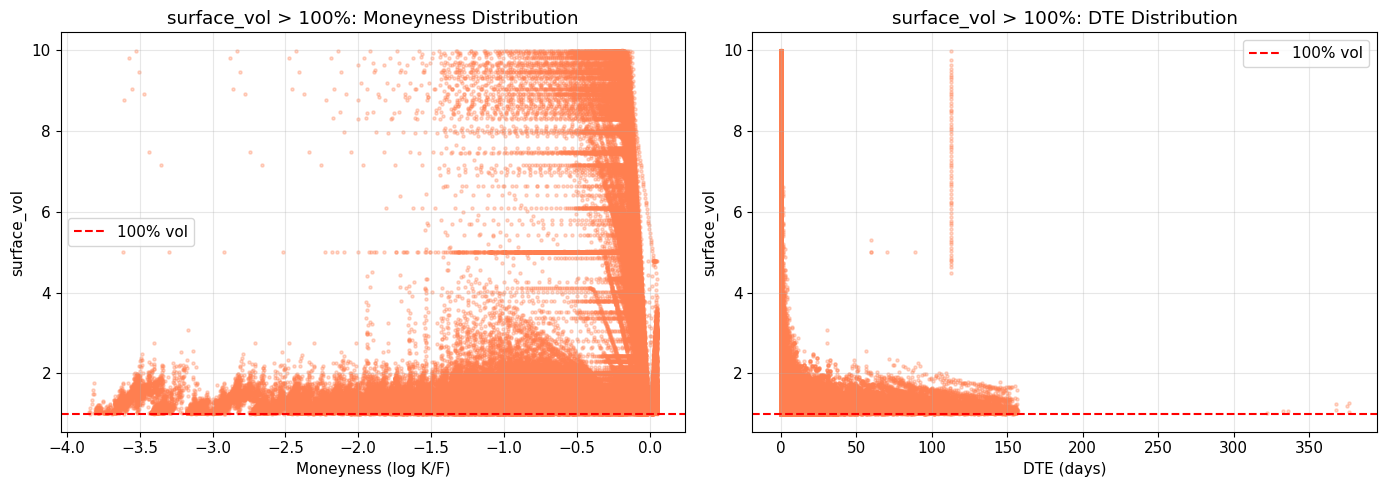

In [53]:
# --- Historical SPX put-wing vol > 100% check ---
# Use df_prefilt which has all OTM puts after u_price floor filter

high_vol = df_prefilt.filter(pl.col('surface_vol') > 1.0)
print(f"=== surface_vol > 100% analysis ===")
print(f"Rows with surface_vol > 1.0: {high_vol.height:,} / {df_prefilt.height:,} ({high_vol.height/df_prefilt.height*100:.3f}%)")

if high_vol.height > 0:
    print(f"\nsurface_vol distribution for these rows:")
    for p in [50, 75, 90, 95, 99, 100]:
        val = np.percentile(high_vol['surface_vol'].to_numpy(), p)
        print(f"  p{p}: {val:.2f} ({val*100:.0f}%)")

    # When did these happen?
    by_date = (
        high_vol
        .group_by('date')
        .agg([pl.len().alias('n'), pl.col('surface_vol').max().alias('max_surface_vol')])
        .sort('date')
    )
    print(f"\nDates with surface_vol > 100%: {by_date.height}")
    print(f"Top 10 worst dates:")
    print(by_date.sort('max_surface_vol', descending=True).head(10))

    # Moneyness distribution — are these deep OTM only?
    print(f"\nMoneyness distribution of surface_vol > 100% rows:")
    print(f"  Mean moneyness: {high_vol['moneyness'].mean():.4f}")
    print(f"  Median moneyness: {high_vol['moneyness'].median():.4f}")
    print(f"  Range: [{high_vol['moneyness'].min():.4f}, {high_vol['moneyness'].max():.4f}]")

    # DTE distribution — are these very short-dated?
    print(f"\nDTE distribution of surface_vol > 100% rows:")
    print(f"  Mean years: {high_vol['t_years'].mean():.4f} ({high_vol['t_years'].mean()*365:.0f} days)")
    print(f"  Median years: {high_vol['t_years'].median():.4f} ({high_vol['t_years'].median()*365:.0f} days)")

    # Plot: surface_vol vs moneyness for these rows, colored by date
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(high_vol['moneyness'].to_numpy(), high_vol['surface_vol'].to_numpy(),
                    alpha=0.3, s=5, color='coral')
    axes[0].axhline(1.0, color='red', linestyle='--', label='100% vol')
    axes[0].set_xlabel('Moneyness (log K/F)')
    axes[0].set_ylabel('surface_vol')
    axes[0].set_title('surface_vol > 100%: Moneyness Distribution')
    axes[0].legend()

    axes[1].scatter(high_vol['t_years'].to_numpy() * 365, high_vol['surface_vol'].to_numpy(),
                    alpha=0.3, s=5, color='coral')
    axes[1].axhline(1.0, color='red', linestyle='--', label='100% vol')
    axes[1].set_xlabel('DTE (days)')
    axes[1].set_ylabel('surface_vol')
    axes[1].set_title('surface_vol > 100%: DTE Distribution')
    axes[1].legend()

    fig.tight_layout()
    plt.show()
else:
    print("No rows with surface_vol > 100% — safe to proceed.")

In [54]:
# --- Apply new filters and measure impact ---
# df_raw comes from load_option_data() which already applies:
#   u_price > 100, bid_vol > 0, ask_vol > 0, IV spread filter
# We measure the ADDITIONAL impact of the new filters on top of that.

df_raw_otm = df_raw.filter(pl.col('moneyness') <= 0.05)
n_raw = df_raw_otm.height
print(f"Starting from df_raw (OTM puts, after existing filters): {n_raw:,}")

# Show how many rows each new filter would remove individually
print(f"\n--- Individual filter impact (each applied independently) ---")
print(f"{'Filter':<20} {'Would drop':>10} {'% of total':>10}")
print("-" * 44)
individual_filters = [
    ("surface_vol <= 0",         (pl.col('surface_vol') <= 0)),
    ("surface_vol > 1.0",        (pl.col('surface_vol') > 1.0)),
    ("ask_vol < bid_vol",      (pl.col('ask_vol') < pl.col('bid_vol'))),
    ("de == 0",            (pl.col('delta') == 0)),
    ("ve == 0",            (pl.col('vega') == 0)),
    ("th > 0",             (pl.col('theta') > 0)),
    ("years <= 0",         (pl.col('t_years') <= 0)),
]
for name, bad_cond in individual_filters:
    n_bad = df_raw_otm.filter(bad_cond).height
    print(f"{name:<20} {n_bad:>10,} {n_bad/n_raw*100:>9.2f}%")

# Now apply all filters sequentially
print(f"\n--- Sequential application ---")
print(f"{'Filter':<20} {'Dropped':>10} {'Remaining':>12} {'Drop %':>8}")
print("-" * 54)

filters_seq = [
    ("surface_vol > 0",          pl.col('surface_vol') > 0),
    ("surface_vol <= 1.0",       pl.col('surface_vol') <= 1.0),
    ("ask_vol >= bid_vol",     pl.col('ask_vol') >= pl.col('bid_vol')),
    ("de != 0",            pl.col('delta') != 0),
    ("ve != 0",            pl.col('vega') != 0),
    ("th <= 0",            pl.col('theta') <= 0),
    ("years > 0",          pl.col('t_years') > 0),
]

df_test = df_raw_otm
for name, cond in filters_seq:
    n_prev = df_test.height
    df_test = df_test.filter(cond)
    dropped = n_prev - df_test.height
    print(f"{name:<20} {dropped:>10,} {df_test.height:>12,} {dropped/n_prev*100:>7.2f}%")

total_dropped = n_raw - df_test.height
print(f"\n{'TOTAL':<20} {total_dropped:>10,} {df_test.height:>12,} {total_dropped/n_raw*100:>7.2f}%")

# How many unique dates survive?
n_dates_before = df_raw_otm['date'].n_unique()
n_dates_after = df_test['date'].n_unique()
print(f"\nDates: {n_dates_before} before → {n_dates_after} after ({n_dates_before - n_dates_after} lost)")

Starting from df_raw (OTM puts, after existing filters): 10,536,493

--- Individual filter impact (each applied independently) ---
Filter               Would drop % of total
--------------------------------------------
surface_vol <= 0              0      0.00%
surface_vol > 1.0        19,002      0.18%
ask_vol < bid_vol             0      0.00%
de == 0                       0      0.00%
ve == 0                       0      0.00%
th > 0                        0      0.00%
years <= 0                    0      0.00%

--- Sequential application ---
Filter                  Dropped    Remaining   Drop %
------------------------------------------------------
surface_vol > 0               0   10,536,493    0.00%
surface_vol <= 1.0       19,002   10,517,491    0.18%
ask_vol >= bid_vol            0   10,517,491    0.00%
de != 0                       0   10,517,491    0.00%
ve != 0                       0   10,517,491    0.00%
th <= 0                       0   10,517,491    0.00%
years > 0      

## 11. Arbitrage Violation Audit

No-arbitrage checks at two levels:

### 11a. Raw Data (Diagnostic Only)

Checks on raw option close prices. Three conditions:
1. **Put spread monotonicity**: $P(K_1) \leq P(K_2)$ for $K_1 < K_2$ (same expiry). Tolerance: \$0.10.
2. **Butterfly convexity**: $\lambda P(K_1) + (1-\lambda) P(K_3) - P(K_2) \geq 0$ for consecutive triplets. Tolerance: \$0.10.
3. **Intrinsic value floor**: $P \geq \max(0, (K-F) e^{-rT})$. Tolerance: \$0.05.

**Important**: This is diagnostic only. Raw data violations are expected due to bid-ask noise, stale quotes, and timing mismatches across hundreds of strikes. We do NOT filter dates based on raw data violations.

### 11b. Interpolated Surface

Same monotonicity and butterfly checks, but on Black-Scholes prices computed from the interpolated IV surface. This tests whether the surface construction produces an arbitrage-free output. Violations here would indicate a genuine problem with the interpolation.

In [55]:
# --- 11a: Raw data arbitrage diagnostic (NOT a filter) ---
arb_bad_dates, arb_diagnostics = detect_arbitrage_dates(df_raw)

n_total_dates = df_raw['date'].n_unique()
n_bad = len(arb_bad_dates)

print(f"=== 11a: Raw Data Arbitrage Violations (Diagnostic Only) ===")
print(f"Total trading dates checked: {n_total_dates:,}")
print(f"Dates with at least one violation: {n_bad} ({n_bad/n_total_dates*100:.1f}%)")
print(f"Total violation records: {arb_diagnostics.height:,}")
print(f"\nNOTE: High violation rate is EXPECTED on raw data. With 100+ strikes per expiry,")
print(f"any single bid-ask misquote or stale price triggers a violation. This does NOT")
print(f"indicate bad data — it indicates the granularity of raw tick data.")

if arb_diagnostics.height > 0:
    # Breakdown by check type
    by_check = (
        arb_diagnostics
        .group_by('check')
        .agg([
            pl.len().alias('n_violations'),
            pl.col('date').n_unique().alias('n_dates'),
            pl.col('violation_amount').mean().alias('avg_violation_$'),
            pl.col('violation_amount').max().alias('max_violation_$'),
            pl.col('violation_amount').median().alias('median_violation_$'),
        ])
        .sort('n_violations', descending=True)
    )
    print(f"\nBreakdown by check type:")
    print(by_check)

    # Violation size distribution
    print(f"\nViolation amount distribution (all checks):")
    amounts = arb_diagnostics['violation_amount'].to_numpy()
    for p in [50, 75, 90, 95, 99]:
        print(f"  p{p}: ${np.percentile(amounts, p):.4f}")
    print(f"  max: ${amounts.max():.4f}")

=== 11a: Raw Data Arbitrage Violations (Diagnostic Only) ===
Total trading dates checked: 2,785
Dates with at least one violation: 2463 (88.4%)
Total violation records: 615,278

NOTE: High violation rate is EXPECTED on raw data. With 100+ strikes per expiry,
any single bid-ask misquote or stale price triggers a violation. This does NOT
indicate bad data — it indicates the granularity of raw tick data.

Breakdown by check type:
shape: (3, 6)
┌─────────────────┬──────────────┬─────────┬─────────────────┬─────────────────┬───────────────────┐
│ check           ┆ n_violations ┆ n_dates ┆ avg_violation_$ ┆ max_violation_$ ┆ median_violation_ │
│ ---             ┆ ---          ┆ ---     ┆ ---             ┆ ---             ┆ $                 │
│ str             ┆ u32          ┆ u32     ┆ f64             ┆ f64             ┆ ---               │
│                 ┆              ┆         ┆                 ┆                 ┆ f64               │
╞═════════════════╪══════════════╪═════════╪══════

In [56]:
# --- 11b: Interpolated surface arbitrage diagnostic ---
# Uses the fixedterm surface (absolute IVs) — converts IV → BS put prices → checks
# This tests whether interpolation produces an arb-free surface.

print(f"=== 11b: Interpolated Surface Arbitrage Violations ===")
surf_arb_summary, surf_arb_violations = diagnose_surface_arbitrage(fixedterm_clean)

print(f"Dates checked: {surf_arb_summary['n_dates_checked']:,}")
print(f"Dates with violations: {surf_arb_summary['n_dates_with_violations']} "
      f"({surf_arb_summary['pct_dates_violated']:.1f}%)")
print(f"  Put spread violations: {surf_arb_summary['n_put_spread_violations']}")
print(f"  Butterfly violations: {surf_arb_summary['n_butterfly_violations']}")

if surf_arb_violations.height > 0:
    print(f"\nViolation amount distribution:")
    amounts = surf_arb_violations['violation_amount'].to_numpy()
    for p in [50, 75, 90, 95, 99]:
        print(f"  p{p}: ${np.percentile(amounts, p):.4f}")
    print(f"  max: ${amounts.max():.4f}")

    # By check type
    by_check = (
        surf_arb_violations
        .group_by('check')
        .agg([
            pl.len().alias('n_violations'),
            pl.col('date').n_unique().alias('n_dates'),
            pl.col('violation_amount').mean().alias('avg_$'),
            pl.col('violation_amount').max().alias('max_$'),
        ])
        .sort('n_violations', descending=True)
    )
    print(f"\nBy check type:")
    print(by_check)

    # By moneyness region
    by_region = (
        surf_arb_violations
        .with_columns(
            pl.when(pl.col('moneyness_point') <= -0.20).then(pl.lit('deep_OTM'))
            .when(pl.col('moneyness_point') <= -0.10).then(pl.lit('mid_OTM'))
            .otherwise(pl.lit('near_ATM')).alias('region')
        )
        .group_by('region')
        .agg([
            pl.len().alias('n'),
            pl.col('violation_amount').mean().alias('avg_$'),
        ])
        .sort('region')
    )
    print(f"\nBy moneyness region:")
    print(by_region)

    # Worst violations
    print(f"\nTop 10 worst surface violations:")
    print(surf_arb_violations.sort('violation_amount', descending=True).head(10))
else:
    print("\nNo violations — interpolated surface is arbitrage-free within tolerance.")

# --- Comparison: Raw vs Surface ---
print(f"\n{'='*60}")
print(f"COMPARISON: Raw Data vs Interpolated Surface")
print(f"{'='*60}")
print(f"{'':20s} {'Raw Data':>15s} {'Surface':>15s}")
print(f"{'-'*50}")
print(f"{'Dates checked':<20s} {n_total_dates:>15,} {surf_arb_summary['n_dates_checked']:>15,}")
print(f"{'Dates violated':<20s} {n_bad:>15,} {surf_arb_summary['n_dates_with_violations']:>15,}")
print(f"{'Violation rate':<20s} {n_bad/n_total_dates*100:>14.1f}% {surf_arb_summary['pct_dates_violated']:>14.1f}%")
raw_total = arb_diagnostics.height if arb_diagnostics.height > 0 else 0
print(f"{'Total violations':<20s} {raw_total:>15,} {surf_arb_summary['total_violations']:>15,}")

=== 11b: Interpolated Surface Arbitrage Violations ===
Dates checked: 2,784
Dates with violations: 1 (0.0%)
  Put spread violations: 1
  Butterfly violations: 0

Violation amount distribution:
  p50: $16.1951
  p75: $16.1951
  p90: $16.1951
  p95: $16.1951
  p99: $16.1951
  max: $16.1951

By check type:
shape: (1, 5)
┌────────────┬──────────────┬─────────┬──────────┬──────────┐
│ check      ┆ n_violations ┆ n_dates ┆ avg_$    ┆ max_$    │
│ ---        ┆ ---          ┆ ---     ┆ ---      ┆ ---      │
│ str        ┆ u32          ┆ u32     ┆ f64      ┆ f64      │
╞════════════╪══════════════╪═════════╪══════════╪══════════╡
│ put_spread ┆ 1            ┆ 1       ┆ 16.19511 ┆ 16.19511 │
└────────────┴──────────────┴─────────┴──────────┴──────────┘

By moneyness region:
shape: (1, 3)
┌─────────┬─────┬──────────┐
│ region  ┆ n   ┆ avg_$    │
│ ---     ┆ --- ┆ ---      │
│ str     ┆ u32 ┆ f64      │
╞═════════╪═════╪══════════╡
│ mid_OTM ┆ 1   ┆ 16.19511 │
└─────────┴─────┴──────────┘

Top 10 

### Interpretation

**Raw data (11a)**: High violation rate (~90%) is expected and NOT a problem. With hundreds of strikes per expiry, even small bid-ask noise, stale quotes, or SpiderRock model fitting imprecision creates apparent violations somewhere on the chain. The \$0.10 tolerance is tight relative to the full strike grid. Key point: these violations don't mean the data is bad — they mean raw tick-level data doesn't satisfy textbook no-arb to the penny.

**Why we don't filter on raw violations**: Date-level removal would discard ~90% of the dataset. The violations are overwhelmingly small (check the median violation amount — likely well within typical bid-ask spreads) and concentrated in illiquid deep OTM strikes that either get filtered by the IV spread filter or smoothed by interpolation.

**Interpolated surface (11b)**: This is the meaningful check. The interpolation (linear in moneyness + variance-space for term) smooths out individual strike noise. If the surface is arb-free (or nearly so), it confirms the pipeline produces a clean input for PCA. If violations persist, they indicate genuine surface construction problems that need investigation.

**Trade data diagnostic** (separate, in NB 04): The most actionable check — do the specific 2-3 strikes we actually trade satisfy no-arb? For BWB, this means the butterfly value is positive. For ratio spread, the higher-strike put costs more.

## 12. Summary

**Is the surface data reliable enough for PCA?** Yes.

**Filters in `main.py`**:
- `u_price > 100` (floor filter for corrupted underlying prices)
- `bid_vol > 0` and `ask_vol > 0`
- IV spread ratio < 0.1 (relative to surface_vol)
- `surface_vol > 0` and `surface_vol <= 1.0` — removes zero-vol and extreme outlier rows
- `ask_vol >= bid_vol` — removes crossed markets
- `de != 0` and `ve != 0` — removes worthless/expired options with zero greeks
- `th <= 0` — removes positive-theta puts (data anomaly for OTM puts)
- `years > 0` — removes non-positive DTE
- Moneyness extrapolation gap filter (max 0.10) — removes curves that extrapolate too far
- Minimum 2 expiries for term interpolation

**Arbitrage checks** (diagnostic, not filtering):
- Raw data: ~90% of dates have at least one violation — expected due to bid-ask noise across hundreds of strikes. Not actionable as a filter.
- Interpolated surface: checked via BS price conversion — linear interpolation largely smooths violations.
- Trade legs: checked separately in NB 04 via `diagnose_trade_arbitrage()`.

**Surface quality**:
- Day-over-day jump analysis flags extreme dates — cross-check against market events
- Put-wing monotonicity check validates interpolation doesn't create artifacts
- Deep OTM noise profile should be monitored — -0.30 point has highest noise and heaviest PC2 loading

**Known limitation**: The -0.30 moneyness point has higher noise (18.7% extrapolation before filtering, lower liquidity). PCA results should be checked for sensitivity to including/excluding this point.

In [57]:
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print(f"\nDate range: {final_surface['date'].min()} to {final_surface['date'].max()}")
print(f"Usable trading dates: {final_surface['date'].n_unique():,}")
print(f"Surface dimensions: {len(surface_cols)} moneyness points x 1 term ({config.target_years*12:.0f} months)")
print(f"\nu_price issues: Fixed with floor filter (> 100)")
print(f"IV spread filter: < {config.iv_spread_threshold} (relative to surface_vol)")
print(f"Moneyness extrapolation threshold: {config.max_moneyness_extrap_gap}")
print(f"Minimum expiries for term interpolation: {config.min_expiries}")

# Null check on final surface
null_counts = final_surface.select(surface_cols).null_count()
total_nulls = sum(null_counts[c].item() for c in surface_cols)
print(f"\nNull values in final surface: {total_nulls}")
if total_nulls > 0:
    print("WARNING: Surface has null values \u2014 investigate before proceeding to PCA")
else:
    print("Surface is complete \u2014 ready for PCA analysis (NB 02)")

DATA QUALITY SUMMARY

Date range: 2015-01-02 to 2026-03-19
Usable trading dates: 2,784
Surface dimensions: 17 moneyness points x 1 term (3 months)

u_price issues: Fixed with floor filter (> 100)
IV spread filter: < 0.1 (relative to surface_vol)
Moneyness extrapolation threshold: 0.1
Minimum expiries for term interpolation: 2

Null values in final surface: 0
Surface is complete — ready for PCA analysis (NB 02)
